In [ ]:
import os
import cv2
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torchvision.models import MobileNet_V2_Weights
from torch.utils.data import DataLoader
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import shutil
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from tqdm import tqdm
from PIL import Image, ImageOps

# Configuration
BATCH_SIZE = 32
IMG_SIZE = 224
EPOCHS = 10

# device configuration
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Apprentissage sur : {device}")

Apprentissage sur : mps


Nombre total d'images : 8208

Répartition exacte par classe :
Classe
0    7864
3     147
2     119
1      73
4       4
6       1
Name: count, dtype: int64


/var/folders/65/_6_vzrxd7ql89tvbx49tn3rr0000gn/T/ipykernel_2043/552610921.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Classe_Nom', palette='viridis')


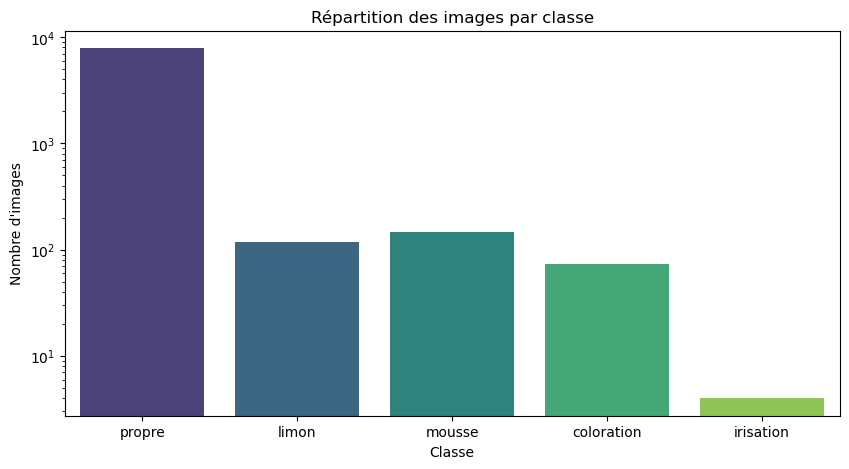

In [3]:
# Chargement du CSV
df = pd.read_csv('dataset_complet.csv')

# Affichage des infos de base
print("Nombre total d'images :", len(df))
print("\nRépartition exacte par classe :")
print(df['Classe'].value_counts())


# Visualisation de la répartition
class_names = {0: "propre", 1: "coloration", 2: "limon", 3: "mousse", 4: "irisation"}
df['Classe_Nom'] = df['Classe'].map(class_names)

plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='Classe_Nom', palette='viridis')
plt.title("Répartition des images par classe")
plt.xlabel("Classe")
plt.ylabel("Nombre d'images")
plt.yscale('log') # On utilise une échelle logarithmique car la classe 0 écrase tout le reste
plt.show()

In [4]:
# Dossier source 
SOURCE_DIR = 'data' 

# Dossier entrainement
TARGET_DIR = 'dataset'

# Filtrage des classes "fantômes" (qui n'ont qu'une seule image)
class_counts = df['Classe'].value_counts()
classes_to_keep = class_counts[class_counts > 1].index
df_clean = df[df['Classe'].isin(classes_to_keep)]
print(f"Images conservées après nettoyage : {len(df_clean)} / {len(df)}")

# Train / Validation (80% / 20%)
# stratify=df_clean['Classe'] même ratio de chaque classe dans train et val
train_df, val_df = train_test_split(df_clean, test_size=0.2, random_state=42, stratify=df_clean['Classe'])

print(f"Taille du jeu d'entraînement : {len(train_df)}")
print(f"Taille du jeu de validation : {len(val_df)}")

# Fonction pour copier les fichiers dans les bons dossiers
def copy_images(dataframe, split_name):
    print(f"\nCopie des images pour le set : {split_name}...")
    for index, row in tqdm(dataframe.iterrows(), total=len(dataframe)):
        img_name = row['Nom_Image']
        img_class = str(row['Classe']) # Le nom du dossier sera le numéro de la classe
        
        # Création du chemin cible : dataset/train/0/ ou dataset/val/1/ etc.
        dest_dir = os.path.join(TARGET_DIR, split_name, img_class)
        os.makedirs(dest_dir, exist_ok=True)
        
        src_path = os.path.join(SOURCE_DIR, img_name)
        dest_path = os.path.join(dest_dir, img_name)
        
        # Copie de l'image (si elle existe bien dans le dossier source)
        if os.path.exists(src_path):
            shutil.copy2(src_path, dest_path)
        else:
            print(f"Attention : L'image {img_name} est introuvable dans le dossier {SOURCE_DIR}.")

# Lancement de la copie
copy_images(train_df, 'train')
copy_images(val_df, 'val')

print("\nTerminé ! L'arborescence est prête pour PyTorch.")

Images conservées après nettoyage : 8207 / 8208
Taille du jeu d'entraînement : 6565
Taille du jeu de validation : 1642

Copie des images pour le set : train...


100%|██████████| 6565/6565 [00:16<00:00, 410.09it/s]



Copie des images pour le set : val...


100%|██████████| 1642/1642 [00:05<00:00, 306.60it/s]


Terminé ! L'arborescence est prête pour PyTorch.


In [5]:

def remove_ir_images(directory, threshold=5.0):
    removed_count = 0
    # Parcourir tous les sous-dossiers (les classes)
    for root, dirs, files in os.walk(directory):
        for file in tqdm(files, desc=f"Vérification dans {os.path.basename(root)}"):
            if file.endswith(('jpg', 'jpeg', 'png')):
                filepath = os.path.join(root, file)
                try:
                    img = Image.open(filepath).convert('RGB')
                    img_np = np.array(img)
                    
                    # On calcule l'écart-type entre les canaux R, G, B
                    # S'il n'y a pas de couleur, la variance entre les canaux est nulle
                    std_dev = np.std(img_np, axis=2)
                    mean_std_dev = np.mean(std_dev)
                    
                    # Si l'écart-type moyen est sous le seuil, c'est du N&B
                    if mean_std_dev < threshold:
                        os.remove(filepath)
                        removed_count += 1
                except Exception as e:
                    print(f"Erreur avec l'image {filepath}: {e}")
                    
    print(f"\nNettoyage terminé pour {directory} : {removed_count} images IR supprimées.")

# Lancement du nettoyage
remove_ir_images('dataset/train')
remove_ir_images('dataset/val')

Vérification dans 2: 100%|██████████| 95/95 [00:23<00:00,  4.04it/s]



Nettoyage terminé pour dataset/train : 4657 images IR supprimées.


Vérification dans 2: 100%|██████████| 24/24 [00:05<00:00,  4.20it/s]


Nettoyage terminé pour dataset/val : 1449 images IR supprimées.


In [22]:


def oversample_minority_classes(train_dir, minority_classes):
    print("Début de la création de nouvelles images (Flips et Rotations)...")
    for cls in minority_classes:
        class_dir = os.path.join(train_dir, str(cls))
        if not os.path.exists(class_dir):
            continue
            
        # On ne sélectionne que les images originales (pour ne pas augmenter des images déjà augmentées)
        files = [f for f in os.listdir(class_dir) if f.endswith(('jpg', 'jpeg', 'png')) 
                 and not ('_flipped' in f or '_rot' in f)]
        
        count = 0
        for file in tqdm(files, desc=f"Augmentation classe {cls}"):
            filepath = os.path.join(class_dir, file)
            try:
                img = Image.open(filepath)
                
                # 1. Création du miroir horizontal
                img_flipped = ImageOps.mirror(img)
                img_flipped.save(os.path.join(class_dir, file.replace('.jpg', '_flipped.jpg')))
                count += 1
                
                # 2. Création des rotations (+15° et -15°)
                for angle in [15, -15]:
                    # fillcolor=(128,128,128) remplit les coins vides en gris neutre
                    # pour éviter de créer des triangles noirs francs qui tromperaient le modèle
                    img_rotated = img.rotate(angle, fillcolor=(128, 128, 128))
                    img_rotated.save(os.path.join(class_dir, file.replace('.jpg', f'_rot{angle}.jpg')))
                    count += 1
                    
            except Exception as e:
                print(f"Erreur avec {file}: {e}")
                
        print(f"Classe {cls} : {count} nouvelles images créées.")

# On n'augmente QUE le dossier d'entraînement, jamais la validation !
oversample_minority_classes('dataset/train', minority_classes=[1, 2, 3])

Début de la création de nouvelles images (Flips et Rotations)...


Augmentation classe 1: 100%|██████████| 58/58 [00:23<00:00,  2.43it/s]


Classe 1 : 174 nouvelles images créées.


Augmentation classe 2: 100%|██████████| 81/81 [00:33<00:00,  2.43it/s]


Classe 2 : 243 nouvelles images créées.


Augmentation classe 3: 100%|██████████| 106/106 [00:43<00:00,  2.44it/s]

Classe 3 : 318 nouvelles images créées.


In [34]:


# --- 1. CRÉATION DU CHARGEUR D'IMAGES SUR-MESURE ---
class ZiploImageFolder(datasets.ImageFolder):
    def __getitem__(self, index):
        # Récupère le chemin exact de l'image et sa classe
        path, target = self.samples[index]
        
        # Charge l'image (format PIL)
        sample = self.loader(path)
        
        # CONDITION MÉTIER : Est-ce une image de la rivière Ziplo ?
        # (On utilise .lower() au cas où ce soit écrit ziplo, Ziplo ou ZIPLO)
        if 'ziplo' in path.lower():
            width, height = sample.size
            # 1. Coupe la moitié supérieure
            sample = sample.crop((0, height // 2, width, height))
            # 2. Padding pour faire un carré parfait
            max_dim = max(sample.size)
            sample = ImageOps.pad(sample, size=(max_dim, max_dim), color=(128, 128, 128))
            
        # Applique le reste des transformations classiques (Resize, Data Augmentation...)
        if self.transform is not None:
            sample = self.transform(sample)
        if self.target_transform is not None:
            target = self.target_transform(target)

        return sample, target

# --- 2. DÉFINITION DES TRANSFORMATIONS CLASSIQUES ---
# On ne met PLUS la coupe ici, car elle est gérée par ZiploImageFolder juste au-dessus !
train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) 
])

val_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# --- 3. CHARGEMENT DES DONNÉES AVEC NOTRE CLASSE CUSTOM ---
# On remplace 'datasets.ImageFolder' par 'ZiploImageFolder'
train_dataset = ZiploImageFolder('dataset/train', transform=train_transforms)
val_dataset = ZiploImageFolder('dataset/val', transform=val_transforms)

NUM_CLASSES = len(train_dataset.classes)
print(f"Nombre de classes détectées automatiquement : {NUM_CLASSES}")
print(f"Noms des classes : {train_dataset.classes}")

# Création des DataLoaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

class_names = train_dataset.classes
print(f"Classes détectées : {class_names}")

Nombre de classes détectées automatiquement : 5
Noms des classes : ['0', '1', '2', '3', '4']
Classes détectées : ['0', '1', '2', '3', '4']


In [35]:
# Charger le modèle
model = models.mobilenet_v2(weights=MobileNet_V2_Weights.IMAGENET1K_V1)

# Geler les paramètres 
for param in model.parameters():
    param.requires_grad = False

# Remplacer la dernière couche (le classifieur)
num_ftrs = model.classifier[1].in_features
model.classifier[1] = nn.Linear(num_ftrs, NUM_CLASSES)

# modèle sur le GPU 
model = model.to(device)

# Définir la fonction de coût et l'optimiseur
train_labels = [label for _, label in train_dataset.samples]

# ajoute un point proportionnel à l'inverse de la fréquence de chaque classe
classes_uniques = np.unique(train_labels)
class_weights = compute_class_weight(class_weight='balanced', 
                                     classes=classes_uniques, 
                                     y=train_labels)

weights_tensor = torch.FloatTensor(class_weights).to(device)
criterion = nn.CrossEntropyLoss(weight=weights_tensor)
# On n'optimise que les paramètres de la nouvelle couche finale
optimizer = optim.Adam(model.classifier.parameters(), lr=0.001)

In [36]:
train_losses, val_losses = [], []

for epoch in range(EPOCHS):
    # --- PHASE D'ENTRAÎNEMENT ---
    model.train() # Passe le modèle en mode entraînement
    running_loss = 0.0
    
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        
        optimizer.zero_grad() # Réinitialiser les gradients
        
        outputs = model(inputs) # Propagation avant (Forward)
        loss = criterion(outputs, labels) # Calcul de l'erreur
        
        loss.backward() # Rétropropagation (Backward)
        optimizer.step() # Mise à jour des poids
        
        running_loss += loss.item() * inputs.size(0)
        
    epoch_train_loss = running_loss / len(train_dataset)
    train_losses.append(epoch_train_loss)
    
    # --- PHASE DE VALIDATION ---
    model.eval() # Passe le modèle en mode évaluation (désactive le Dropout par ex)
    val_loss = 0.0
    correct = 0
    
    with torch.no_grad(): # On ne calcule pas les gradients pour la validation
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * inputs.size(0)
            
            _, preds = torch.max(outputs, 1)
            correct += torch.sum(preds == labels.data)
            
    epoch_val_loss = val_loss / len(val_dataset)
    val_losses.append(epoch_val_loss)
    epoch_acc = correct.float() / len(val_dataset)
    
    print(f"Epoch {epoch+1}/{EPOCHS} - Train Loss: {epoch_train_loss:.4f} - Val Loss: {epoch_val_loss:.4f} - Val Acc: {epoch_acc:.4f}")

Epoch 1/10 - Train Loss: 1.1444 - Val Loss: 0.7979 - Val Acc: 0.7954
Epoch 2/10 - Train Loss: 0.8641 - Val Loss: 0.3927 - Val Acc: 0.9020
Epoch 3/10 - Train Loss: 0.7010 - Val Loss: 0.5636 - Val Acc: 0.8127
Epoch 4/10 - Train Loss: 0.6432 - Val Loss: 0.4626 - Val Acc: 0.8804
Epoch 5/10 - Train Loss: 0.5933 - Val Loss: 0.3846 - Val Acc: 0.9063
Epoch 6/10 - Train Loss: 0.5739 - Val Loss: 0.4325 - Val Acc: 0.8689
Epoch 7/10 - Train Loss: 0.5427 - Val Loss: 0.2872 - Val Acc: 0.9452
Epoch 8/10 - Train Loss: 0.5060 - Val Loss: 0.3474 - Val Acc: 0.9049
Epoch 9/10 - Train Loss: 0.5017 - Val Loss: 0.3535 - Val Acc: 0.9107
Epoch 10/10 - Train Loss: 0.5326 - Val Loss: 0.3306 - Val Acc: 0.9179


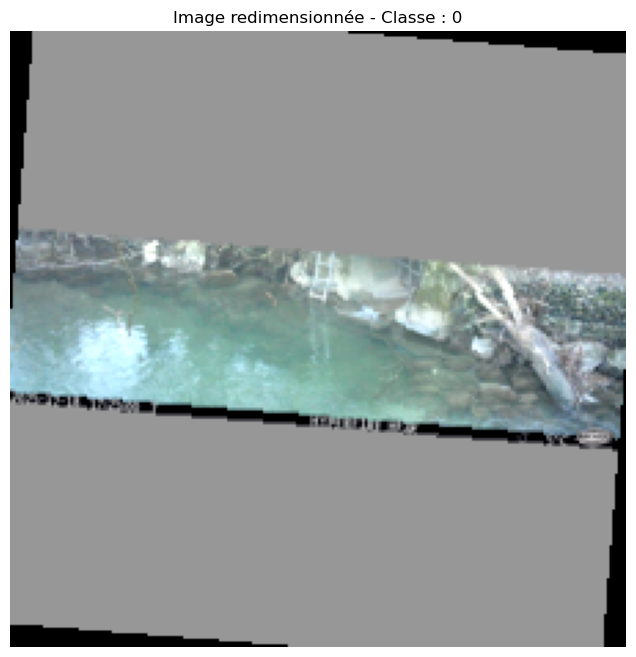

Format du tenseur envoyé au modèle : torch.Size([3, 224, 224])


In [37]:
import matplotlib.pyplot as plt
import numpy as np

# On "pioche" un seul batch (paquet de 32 images) dans notre DataLoader
inputs, labels = next(iter(train_loader))

# On isole la toute première image et sa classe
img_tensor = inputs[0]
label_idx = labels[0].item()
class_name = train_dataset.classes[label_idx]

# PyTorch stocke en format (Canaux, Hauteur, Largeur) soit (3, 384, 384)
# Matplotlib a besoin du format (Hauteur, Largeur, Canaux) soit (384, 384, 3)
img_numpy = img_tensor.permute(1, 2, 0).numpy()

# Dé-normalisation (On fait l'inverse de la transformation PyTorch)
mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])
img_unnormalized = std * img_numpy + mean

# On s'assure que les valeurs restent bien bloquées entre 0 et 1 pour l'affichage
img_ready = np.clip(img_unnormalized, 0, 1)

# Affichage !
plt.figure(figsize=(8, 8))
plt.imshow(img_ready)
plt.title(f"Image redimensionnée - Classe : {class_name}")
plt.axis('off') # On enlève les axes gradués
plt.show()

print(f"Format du tenseur envoyé au modèle : {img_tensor.shape}")

Rapport de Classification :

              precision    recall  f1-score   support

           0       0.98      0.93      0.95       632
           1       0.52      0.93      0.67        15
           2       0.79      0.75      0.77        20
           3       0.44      0.81      0.57        26
           4       0.00      0.00      0.00         1

    accuracy                           0.92       694
   macro avg       0.55      0.68      0.59       694
weighted avg       0.94      0.92      0.93       694



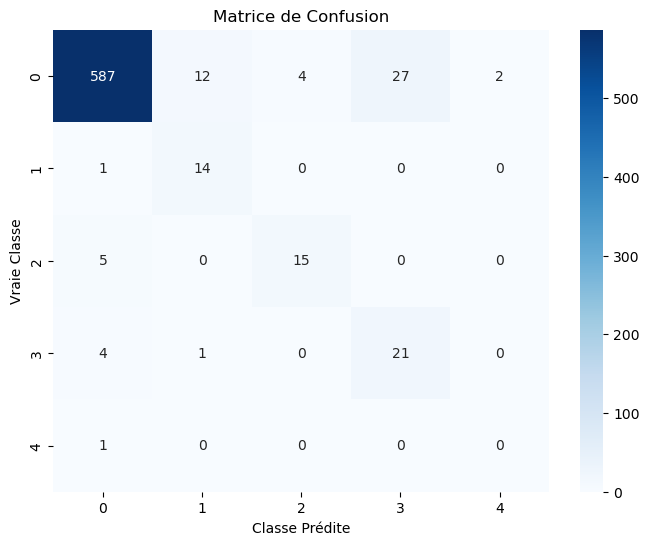

In [38]:
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for inputs, labels in val_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Rapport de classification (inclut le F1-Score)
print("Rapport de Classification :\n")
print(classification_report(all_labels, all_preds, target_names=class_names))

# Matrice de confusion
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.ylabel('Vraie Classe')
plt.xlabel('Classe Prédite')
plt.title('Matrice de Confusion')
plt.show()

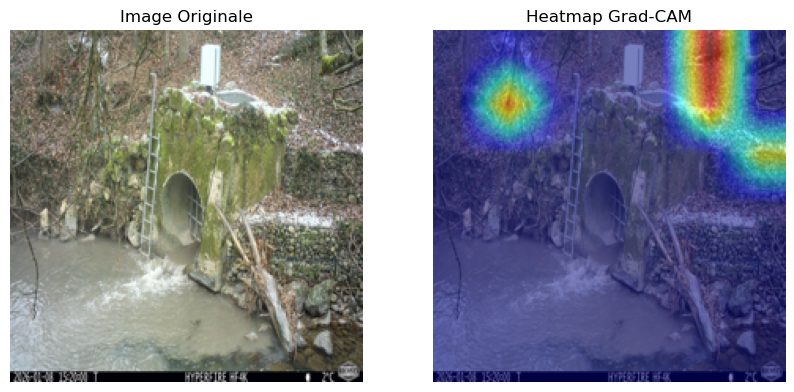

In [ ]:
# --- CORRECTION ICI : On dégèle le modèle pour permettre à Grad-CAM de calculer ses dérivées ---
for param in model.parameters():
    param.requires_grad = True
# ---------------------------------------------------------------------------------------------

# indique à Grad-CAM quelle est la dernière couche de convolution du modèle
# Pour MobileNetV2, c'est 'features[-1]'
target_layers = [model.features[-1]]

# initialise Grad-CAM
cam = GradCAM(model=model, target_layers=target_layers)

def display_heatmap(img_path, model, cam_explainer):
    # Chargement et préparation de l'image
    img = Image.open(img_path).convert('RGB')
    img_resized = img.resize((IMG_SIZE, IMG_SIZE)) 
    
    # Transformation PyTorch
    preprocess = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    input_tensor = preprocess(img_resized).unsqueeze(0).to(device) # Ajout de la dimension batch
    
    # Génération de la Heatmap
    model.eval()
    grayscale_cam = cam_explainer(input_tensor=input_tensor)[0, :]
    
    # image originale 
    img_float = np.float32(img_resized) / 255
    visualization = show_cam_on_image(img_float, grayscale_cam, use_rgb=True)
    
    # Affichage
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(img_resized)
    plt.title("Image Originale")
    plt.axis('off')
    
    plt.subplot(1, 2, 2)
    plt.imshow(visualization)
    plt.title("Heatmap Grad-CAM")
    plt.axis('off')
    plt.show()

# Teste avec une image de pollution de ton dataset de validation
image_test_path = 'dataset/val/2/08032022_142500_RCNX4085_Avril.jpg' 
display_heatmap(image_test_path, model, cam)

In [26]:
# On recharge les dossiers normalement
binary_train_dataset = datasets.ImageFolder('dataset/train', transform=train_transforms)
binary_val_dataset = datasets.ImageFolder('dataset/val', transform=val_transforms)

# On garde num_workers=2 car il n'y a plus de fonction bloquante !
binary_train_loader = DataLoader(binary_train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
binary_val_loader = DataLoader(binary_val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print("DataLoaders Binaires prêts !")

DataLoaders Binaires prêts !


In [ ]:
# Charger un nouveau MobileNetV2
model_binary = models.mobilenet_v2(weights=MobileNet_V2_Weights.IMAGENET1K_V1)

#  Geler les paramètres
for param in model_binary.parameters():
    param.requires_grad = False

# Remplacer la dernière couche (2 classes)
num_ftrs_bin = model_binary.classifier[1].in_features
model_binary.classifier[1] = nn.Linear(num_ftrs_bin, 2)
model_binary = model_binary.to(device)

# Recalculer les poids des classes
# On fait la conversion 0/1 directement ici dans une liste (Compréhension de liste Python)
binary_train_labels = [0 if label == 0 else 1 for _, label in binary_train_dataset.samples]
bin_classes_unique = np.unique(binary_train_labels)

bin_class_weights = compute_class_weight(class_weight='balanced', 
                                         classes=bin_classes_unique, 
                                         y=binary_train_labels)

print(f"Poids binaires calculés (Propre vs Pollué) : {bin_class_weights}")

# Définir la nouvelle perte (Loss) et l'optimiseur
weights_tensor_bin = torch.FloatTensor(bin_class_weights).to(device)
criterion_binary = nn.CrossEntropyLoss(weight=weights_tensor_bin)
optimizer_binary = optim.Adam(model_binary.classifier.parameters(), lr=0.001)

Poids binaires calculés (Propre vs Pollué) : [0.74698492 1.51220753]


In [28]:
bin_train_losses, bin_val_losses = [], []

for epoch in range(EPOCHS):
    # --- ENTRAÎNEMENT ---
    model_binary.train()
    running_loss = 0.0
    
    for inputs, labels in binary_train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        
        # --- L'ASTUCE EST ICI ---
        # Si le label est > 0 (mousse, huile...), ça devient True (1). Sinon False (0).
        # .long() convertit le True/False en format entier PyTorch attendu.
        labels = (labels > 0).long()
        # ------------------------
        
        optimizer_binary.zero_grad()
        
        outputs = model_binary(inputs)
        loss = criterion_binary(outputs, labels)
        loss.backward()
        optimizer_binary.step()
        
        running_loss += loss.item() * inputs.size(0)
        
    epoch_train_loss = running_loss / len(binary_train_dataset)
    bin_train_losses.append(epoch_train_loss)
    
    # --- VALIDATION ---
    model_binary.eval()
    val_loss = 0.0
    correct = 0
    
    with torch.no_grad():
        for inputs, labels in binary_val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            
            # --- LA MÊME ASTUCE POUR LA VALIDATION ---
            labels = (labels > 0).long()
            # -----------------------------------------
            
            outputs = model_binary(inputs)
            loss = criterion_binary(outputs, labels)
            val_loss += loss.item() * inputs.size(0)
            
            _, preds = torch.max(outputs, 1)
            correct += torch.sum(preds == labels.data)
            
    epoch_val_loss = val_loss / len(binary_val_dataset)
    bin_val_losses.append(epoch_val_loss)
    epoch_acc = correct.float() / len(binary_val_dataset)
    
    print(f"Epoch {epoch+1}/{EPOCHS} [BINAIRE] - Train Loss: {epoch_train_loss:.4f} - Val Loss: {epoch_val_loss:.4f} - Val Acc: {epoch_acc:.4f}")

Epoch 1/10 [BINAIRE] - Train Loss: 0.4432 - Val Loss: 0.2368 - Val Acc: 0.9280
Epoch 2/10 [BINAIRE] - Train Loss: 0.3280 - Val Loss: 0.2388 - Val Acc: 0.9265
Epoch 3/10 [BINAIRE] - Train Loss: 0.2906 - Val Loss: 0.2260 - Val Acc: 0.9352
Epoch 4/10 [BINAIRE] - Train Loss: 0.2836 - Val Loss: 0.1819 - Val Acc: 0.9496
Epoch 5/10 [BINAIRE] - Train Loss: 0.2434 - Val Loss: 0.2348 - Val Acc: 0.9236
Epoch 6/10 [BINAIRE] - Train Loss: 0.2491 - Val Loss: 0.2200 - Val Acc: 0.9280
Epoch 7/10 [BINAIRE] - Train Loss: 0.2572 - Val Loss: 0.1773 - Val Acc: 0.9510
Epoch 8/10 [BINAIRE] - Train Loss: 0.2563 - Val Loss: 0.2259 - Val Acc: 0.9251
Epoch 9/10 [BINAIRE] - Train Loss: 0.2537 - Val Loss: 0.2875 - Val Acc: 0.9092
Epoch 10/10 [BINAIRE] - Train Loss: 0.2542 - Val Loss: 0.2364 - Val Acc: 0.9265


RÉSULTATS DU MODÈLE PUREMENT BINAIRE (MODÈLE B)

              precision    recall  f1-score   support

  Propre (0)       0.98      0.94      0.96       632
  Pollué (1)       0.56      0.82      0.67        62

    accuracy                           0.93       694
   macro avg       0.77      0.88      0.81       694
weighted avg       0.94      0.93      0.93       694



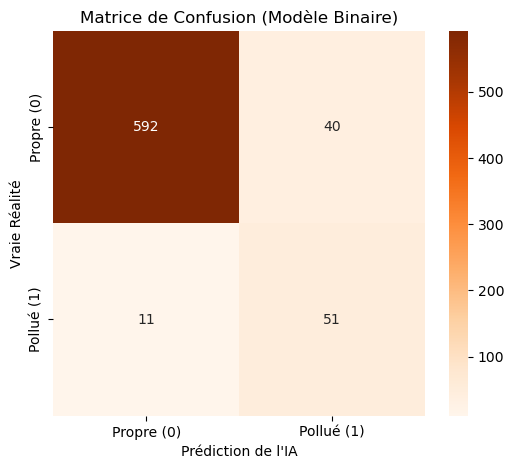

In [29]:
model_binary.eval()
bin_all_preds = []
bin_all_labels = []

with torch.no_grad():
    for inputs, labels in binary_val_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        
        # On convertit les vraies étiquettes en binaire pour le score
        labels = (labels > 0).long()
        
        outputs = model_binary(inputs)
        _, preds = torch.max(outputs, 1)
        
        bin_all_preds.extend(preds.cpu().numpy())
        bin_all_labels.extend(labels.cpu().numpy())

binary_class_names = ["Propre (0)", "Pollué (1)"]

print("=====================================================")
print("RÉSULTATS DU MODÈLE PUREMENT BINAIRE (MODÈLE B)")
print("=====================================================\n")

print(classification_report(bin_all_labels, bin_all_preds, target_names=binary_class_names))

cm_bin_pure = confusion_matrix(bin_all_labels, bin_all_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_bin_pure, annot=True, fmt='d', cmap='Oranges', xticklabels=binary_class_names, yticklabels=binary_class_names)
plt.ylabel('Vraie Réalité')
plt.xlabel('Prédiction de l\'IA')
plt.title('Matrice de Confusion (Modèle Binaire)')
plt.show()